# XYZ model (N = 10)

We simulate an open-boundary XYZ spin chain with couplings  
$J_X = 1$, $J_Y = -1$, and $J_Z = J_X/10 = 0.1$ (so $J_X = -J_Y$).

**Simulation parameters**
- $\ell = 5$
- $m = 2$
- $\epsilon = 10^{-8}$

---

## Truncation schemes

### HS truncation (Pauli-string cutoff)
Classical Pauli-string truncation: any correlator with support size $> m$ is projected to zero.

### Covariance truncation (state-aware)
Any correlator with support size $> m$ is projected onto its **children terms** with support size $\le m$.  
The coefficients of the resulting operator are computed with respect to a **referential state** $\sigma_{\rm ref}$, which may coincide with the initial state.

---

## Jordan–Wigner mini-example

Let
$$
P_{ij}=X_i Z_{i+1}\cdots Z_{j-1}X_j
$$
and choose a product referential state
$$
\sigma_{\rm ref}=\tfrac12\bigotimes_j(\mathbb{I}+r Z_j).
$$

Then, for $m=2$,
$$
\pi^{\sigma_{\rm ref}}_{m=2}(P_{ij})=r^{\,j-i}\,X_iX_j.
$$

Interpretation: $\sigma_{\rm ref}$ “recognizes” the $Z$-polarization structure, the gaussian structure, hidden and of non-local character in the spin-representation, and discounts the JW $Z$-string factors, compressing the nonlocal operator into the physically relevant endpoint correlator $X_iX_j$, with a weight controlled by $r$.
Since the polarization of the X,Y operators is 0, they cannot be treated as classical variables and represent purely quantum correlations. 

---

## Maximal polarization limit

For $r=1$ (maximal polarization), one can show
$$
\| (1-\pi_2)P_{ij}\|_{\mathrm{cov},\,\sigma_{\rm ref}}
=\sqrt{1-r^{2(j-i)}},
$$
which vanishes at $r=1$.

---

## Why this model

We use a weakly broken XY chain (open boundaries) quenched by a small $J_Z\,ZZ$ interaction with $J_Z=J_X/10$.

The dynamics should remain **quasi-Gaussian** for long times, with **stabilizerness increasing slowly**. This makes it a clean setting where covariance-based truncation can outperform naive Pauli-string truncation, because it can compress long JW strings instead of discarding them.


Here, we choose 

# Case 1: My ansatz wins over if sigma0 = GLOBAL_UP_Z

In [22]:
# --- Inputs: set your two paths here ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

folder_path_ = "/home/tomas/phoenix/data/"
_file_path = "/timeseries.csv"
# Required
path_hs    = Path(
            folder_path_ +
            "20260205_153944__XY__N10__ell5__m2__eps1e-10__ptail2__dt4.000e-03__tmax0.4__seedZ0__sigma_HS"
            + _file_path
            ).expanduser()
path_covar = Path(
            folder_path_ +
            "20260205_153850__XY__N10__ell5__m2__eps1e-10__ptail2__dt4.000e-03__tmax0.4__seedZ0__sigmaZ-global"
            + _file_path
            ).expanduser()

observable_col_preference = None

# Plot
PLOT_DPI = 140


/tmp/ipykernel_74467/1357170706.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


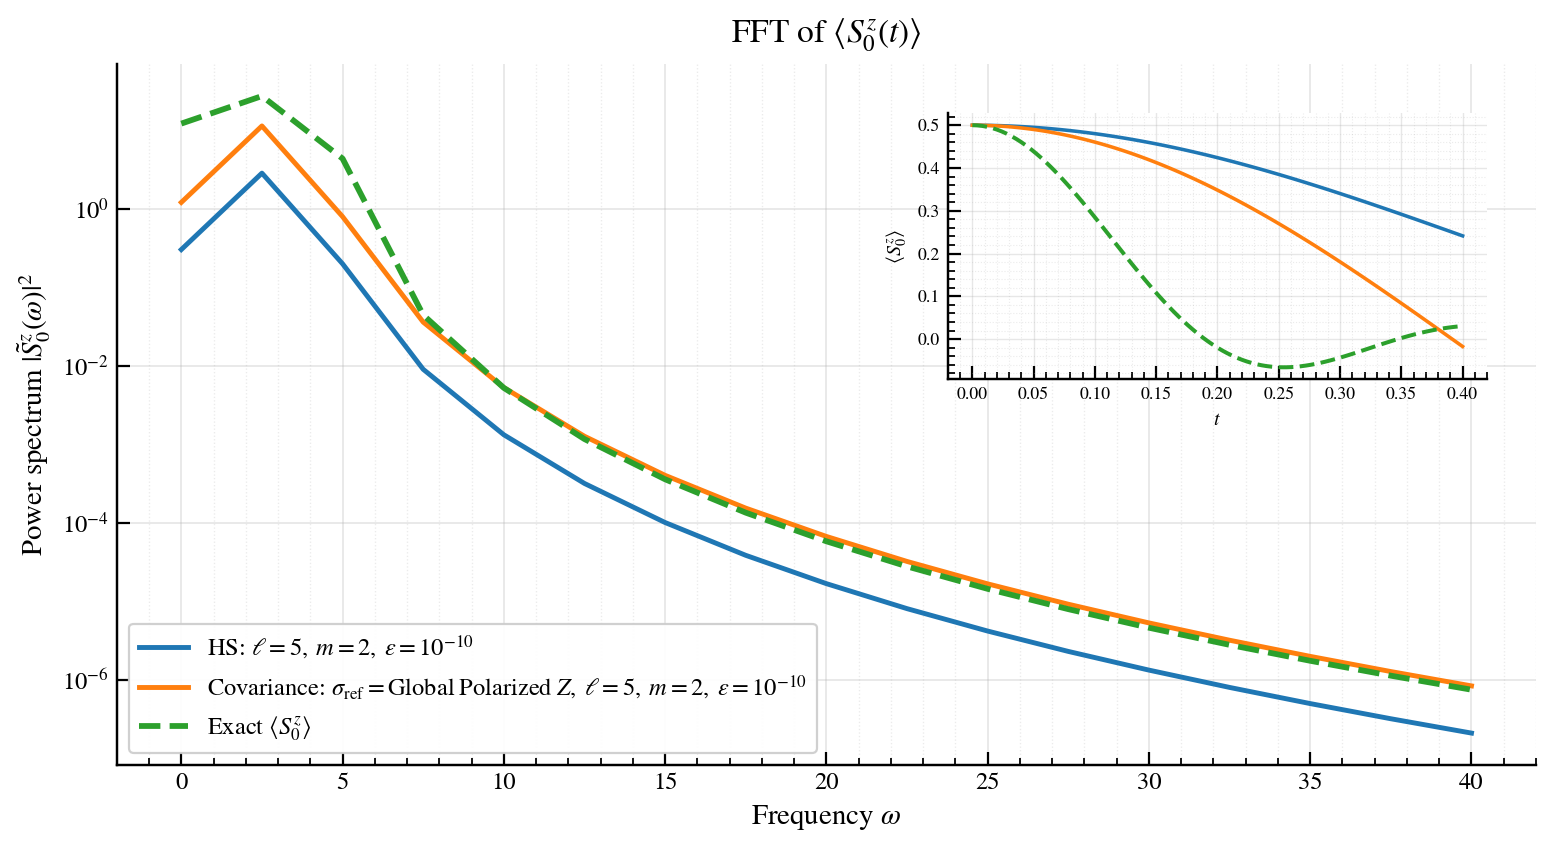

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -------------------------
# FFT (same as before)
# -------------------------
t = aligned["t"][:100].to_numpy()
dt = np.mean(np.diff(t))

def fft_spectrum(y):
    y = np.asarray(y)
    window = np.hanning(len(y))
    yf = np.fft.rfft(y * window)
    freqs = np.fft.rfftfreq(len(y), d=dt)
    power = np.abs(yf)**2
    return freqs, power

y_hs    = aligned["y_hs"].to_numpy()[:100]  - np.mean(aligned["y_hs"].to_numpy()[:100])
y_cov   = aligned["y_cov"].to_numpy()[:100] - np.mean(aligned["y_cov"].to_numpy()[:100])
y_exact = exp_Sz0[:100]                     - np.mean(exp_Sz0[:100])

f_hs,  P_hs  = fft_spectrum(y_hs)
f_cov, P_cov = fft_spectrum(y_cov)
f_ex,  P_ex  = fft_spectrum(y_exact)

f_max = 40.0
mask = f_hs <= f_max

# -------------------------
# Figure + main FFT axis
# -------------------------
fig, ax = plt.subplots(figsize=(9.8, 5.4), dpi=160)

ax.plot(
    f_hs[mask], P_hs[mask], lw=2.2,
    label=r"HS: $\ell=5,\; m=2,\; \varepsilon=10^{-10}$"
)
ax.plot(
    f_cov[mask], P_cov[mask], lw=2.2,
    label=(
        r"Covariance: $\sigma_{\rm ref}=\mathrm{Global\;Polarized}\;Z,$"
        r"$\; \ell=5,\; m=2,\; \varepsilon=10^{-10}$"
    )
)
ax.plot(
    f_ex[mask], P_ex[mask], lw=2.6, ls="--",
    label=r"Exact $\langle S^z_0\rangle$"
)

ax.set_xlabel(r"Frequency $\omega$")
ax.set_ylabel(r"Power spectrum $|\tilde{S}^z_0(\omega)|^2$")
ax.set_title(r"FFT of $\langle S^z_0(t)\rangle$")
ax.set_yscale("log")

ax.minorticks_on()
ax.grid(which="major", linewidth=0.8, alpha=0.30)
ax.grid(which="minor", linestyle=":", linewidth=0.6, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="lower left")

# -------------------------
# Inset: time-domain plot
# -------------------------
axins = inset_axes(
    ax,
    width="38%",    # relative to parent
    height="38%",
    loc="upper right",
    borderpad=2.0,
)

axins.plot(
    aligned["t"],
    aligned["y_hs"],
    linewidth=1.6,
    label="HS",
)
axins.plot(
    aligned["t"],
    aligned["y_cov"],
    linewidth=1.6,
    label="Cov",
)
axins.plot(
    aligned["t"][:-1],
    exp_Sz0,
    linestyle="--",
    linewidth=1.8,
    label="Exact",
)

axins.set_xlabel(r"$t$", fontsize=9)
axins.set_ylabel(r"$\langle S^z_0\rangle$", fontsize=9)
axins.tick_params(labelsize=8)
axins.minorticks_on()

axins.grid(which="major", linewidth=0.6, alpha=0.30)
axins.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.25)

axins.spines["top"].set_visible(False)
axins.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


I studied longer-term evolutions (t > 2J, J =1), a bit unstable in orange due to bugs, but it seems that for very long term simulations, HS wins over my technique but is not really good overall. This is a mathematical curiosity, such longer term simulations are costly for big systems and I'd expect, not of much interest unless the system of study is integrable/GGE/has a quasi fixed point.

Here, we choose 

# Case 2: My ansatz is equiv. to HS & standard Pauli truncation for bad referential states, example sigma0 = 1/2 prod_j (id + .5 x + .5 y)_j

## Case 2: “Bad” referential state

If, instead, we choose a *poor* referential state—e.g. one not aligned with the $Z$ axis and therefore unable (or unwilling) to “see” the JW $Z$-string structure or preserve the near-Gaussian character of the dynamics—then the covariance projection provides no advantage.

In that regime, the ansatz effectively reduces to standard Pauli-string truncation: long-range correlations are not compressed into short operators in a meaningful, state-aware way, and the resulting dynamics match what one obtains from a naive HS cutoff.

**Takeaway.** For the method to succeed, it is not enough that non-stabilizerness grows slowly (as in weakly broken XY + quench, weakly Gaussian regimes, NV-center–like arrays, etc.). The *referential state* must also be compatible with the dominant operator-growth channel, so that the projection both (i) tracks the correct “shape” of correlations and (ii) preserves the relevant quasi-Gaussian structure over time.


In [ ]:
# --- Inputs: set your two paths here ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

folder_path_ = "/home/tomas/phoenix/data/"
_file_path = "/timeseries.csv"
# Required
path_hs    = Path(
            folder_path_ +
    "20260205_153944__XY__N10__ell5__m2__eps1e-10__ptail2__dt4.000e-03__tmax0.4__seedZ0__sigma_HS"
            + _file_path
            ).expanduser()
path_covar = Path(
            folder_path_ +
            "20260205_161546__XY__N10__ell5__m2__eps1e-10__ptail2__dt4.000e-03__tmax0.4__seedZ0__sigma0.5X+Y"
            + _file_path
            ).expanduser()

# If you want to force a specific observable column name, set it here. Otherwise it's auto-detected.
observable_col_preference = None

# Plot
PLOT_DPI = 140


/tmp/ipykernel_74467/1357170706.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


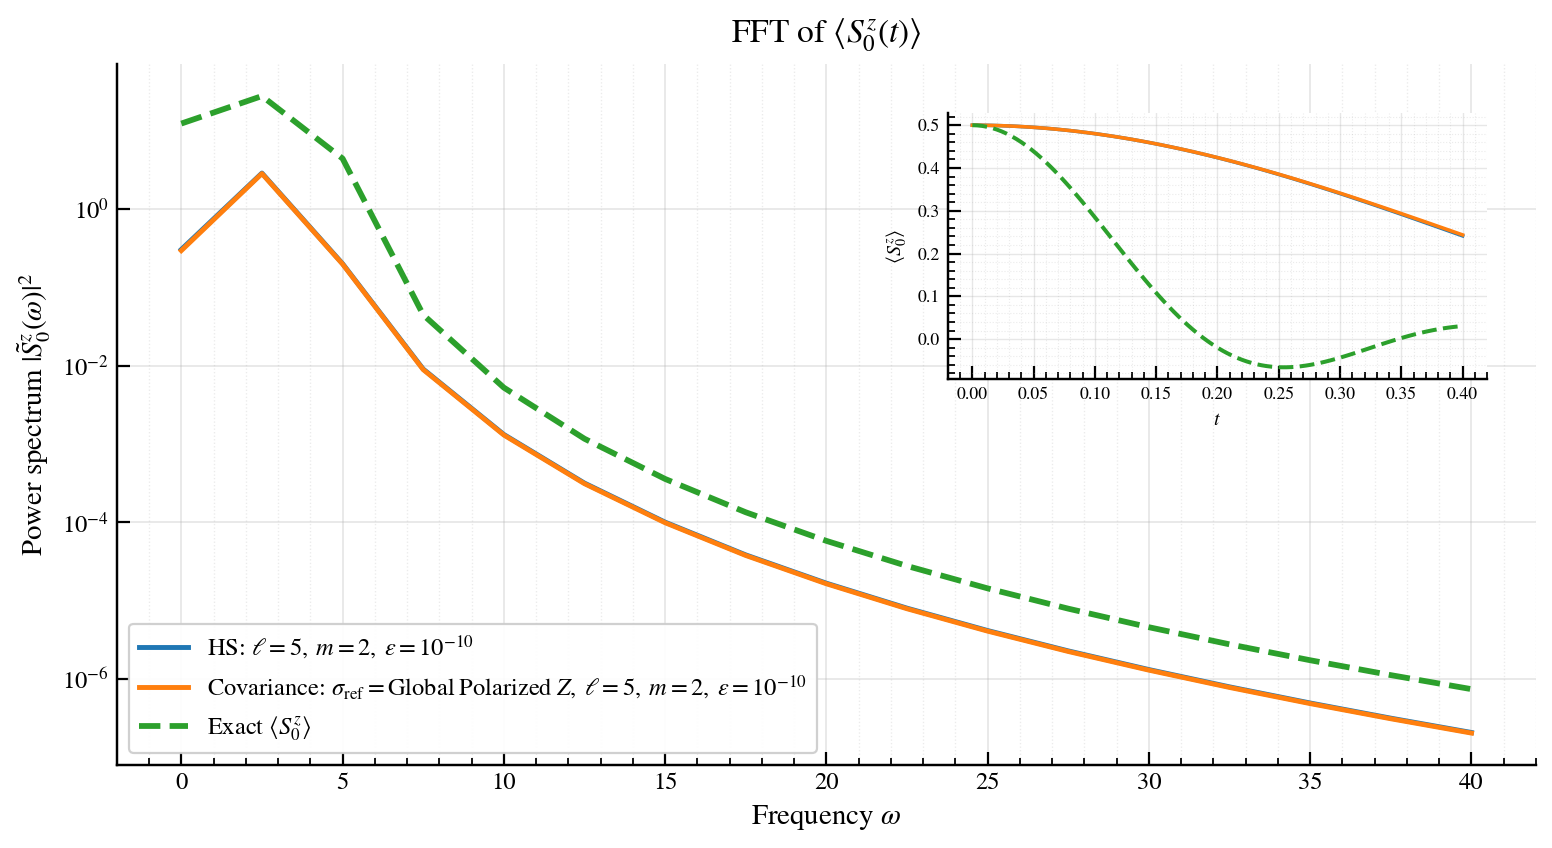

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -------------------------
# FFT (same as before)
# -------------------------
t = aligned["t"][:100].to_numpy()
dt = np.mean(np.diff(t))

def fft_spectrum(y):
    y = np.asarray(y)
    window = np.hanning(len(y))
    yf = np.fft.rfft(y * window)
    freqs = np.fft.rfftfreq(len(y), d=dt)
    power = np.abs(yf)**2
    return freqs, power

y_hs    = aligned["y_hs"].to_numpy()[:100]  - np.mean(aligned["y_hs"].to_numpy()[:100])
y_cov   = aligned["y_cov"].to_numpy()[:100] - np.mean(aligned["y_cov"].to_numpy()[:100])
y_exact = exp_Sz0[:100]                     - np.mean(exp_Sz0[:100])

f_hs,  P_hs  = fft_spectrum(y_hs)
f_cov, P_cov = fft_spectrum(y_cov)
f_ex,  P_ex  = fft_spectrum(y_exact)

f_max = 40.0
mask = f_hs <= f_max

# -------------------------
# Figure + main FFT axis
# -------------------------
fig, ax = plt.subplots(figsize=(9.8, 5.4), dpi=160)

ax.plot(
    f_hs[mask], P_hs[mask], lw=2.2,
    label=r"HS: $\ell=5,\; m=2,\; \varepsilon=10^{-10}$"
)
ax.plot(
    f_cov[mask], P_cov[mask], lw=2.2,
    label=(
        r"Covariance: $\sigma_{\rm ref}=\mathrm{Global\;Polarized}\;Z,$"
        r"$\; \ell=5,\; m=2,\; \varepsilon=10^{-10}$"
    )
)
ax.plot(
    f_ex[mask], P_ex[mask], lw=2.6, ls="--",
    label=r"Exact $\langle S^z_0\rangle$"
)

ax.set_xlabel(r"Frequency $\omega$")
ax.set_ylabel(r"Power spectrum $|\tilde{S}^z_0(\omega)|^2$")
ax.set_title(r"FFT of $\langle S^z_0(t)\rangle$")
ax.set_yscale("log")

ax.minorticks_on()
ax.grid(which="major", linewidth=0.8, alpha=0.30)
ax.grid(which="minor", linestyle=":", linewidth=0.6, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="lower left")

# -------------------------
# Inset: time-domain plot
# -------------------------
axins = inset_axes(
    ax,
    width="38%",    # relative to parent
    height="38%",
    loc="upper right",
    borderpad=2.0,
)

axins.plot(
    aligned["t"],
    aligned["y_hs"],
    linewidth=1.6,
    label="HS",
)
axins.plot(
    aligned["t"],
    aligned["y_cov"],
    linewidth=1.6,
    label="Cov",
)
axins.plot(
    aligned["t"][:-1],
    exp_Sz0,
    linestyle="--",
    linewidth=1.8,
    label="Exact",
)

axins.set_xlabel(r"$t$", fontsize=9)
axins.set_ylabel(r"$\langle S^z_0\rangle$", fontsize=9)
axins.tick_params(labelsize=8)
axins.minorticks_on()

axins.grid(which="major", linewidth=0.6, alpha=0.30)
axins.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.25)

axins.spines["top"].set_visible(False)
axins.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


Bad reference state = no gains, have a 0-level assurance of not being worse than HS, in this case at least.